# v1 Fantasy Football Draft Projection Model — Deliverable

Per CONTEXT.md/PRD (#1): a Projection per Veteran, expressed as a **PPG Projection** (P10/P50/P90
quantiles) and a **Games-Played Estimate**, combined into a **full Projection**. This notebook is the
v1 deliverable per ADR-0008: a CSV/dataframe of Projections plus this visualization + backtest report.
No API layer (that's v1.1, per ADR-0008).

In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)
projections = pd.read_csv("../output/v1_projections.csv")
with open("../output/backtest_report.json") as f:
    backtest_report = json.load(f)

projections.shape

(354, 48)

## Final Projections

All four positions' full Projections (train through 2024, target season **2025** — the first
genuinely future season: nflverse's weekly data confirms 2024 is fully available but 2025 is not
yet published, so 2024 is the most recent valid holdout and 2025 is the earliest un-played target),
combined into one dataframe — the CSV deliverable itself. Each position uses its own winning
multi-season memory window (QB: last 3 seasons; RB/WR/TE: recency-weighted decay) alongside the
original single-season features, per `docs/research/multi-season-memory-features.md`.
`full_projection_p50` is the season-total point estimate (`fantasy_points_p50 *
games_played_estimate`); `full_projection_p10`/`full_projection_p90` are its boom/bust range.

In [2]:
projections.groupby("position").size().rename("players_projected")

position
QB     56
RB     80
TE     74
WR    144
Name: players_projected, dtype: int64

In [4]:
key_columns = [
    "position", "player_name", "target_season", "games_played_estimate",
    "fantasy_points_p10", "fantasy_points_p50", "fantasy_points_p90",
    "full_projection_p10", "full_projection_p50", "full_projection_p90",
]
projections[key_columns].sort_values(
    ["position", "full_projection_p50"], ascending=[True, False]
).groupby("position").head(5)

,position,player_name,target_season,games_played_estimate,fantasy_points_p10,fantasy_points_p50,fantasy_points_p90,full_projection_p10,full_projection_p50,full_projection_p90
39,QB,Jalen Hurts,2025,16.000000,6.341851,23.806250,31.558801,101.469618,380.900007,504.940809
42,QB,Justin Fields,2025,14.125000,0.815478,14.248334,27.521983,11.518631,201.257718,388.748008
9,QB,Derek Carr,2025,14.250000,5.071856,13.684773,22.124180,72.273942,195.008009,315.269568
16,QB,Jared Goff,2025,6.862434,6.885620,18.911258,25.516342,47.252109,129.777256,175.104211
15,QB,Dak Prescott,2025,6.862434,6.362057,16.675492,25.778796,43.659195,114.434458,176.905280
72,RB,Saquon Barkley,2025,8.150685,2.604884,18.011675,31.880926,21.231586,146.807489,259.851381
65,RB,Joe Mixon,2025,8.150685,3.784400,17.693997,29.760339,30.845456,144.218199,242.567145
84,RB,Josh Jacobs,2025,8.150685,2.534407,17.088449,31.217998,20.657150,139.282560,254.448066
58,RB,Derrick Henry,2025,8.022556,2.604884,17.339549,32.835663,20.897826,139.107508,263.425961
59,RB,Christian McCaffrey,2025,8.150685,2.082298,15.130880,26.271890,16.972152,123.327034,214.133897


## Boom/Bust Ranges (P10/P50/P90)

Top 12 players per position by `full_projection_p50`, with the P10-P90 range as an error bar — the
"boom/bust" spread the PRD asks for, not a single collapsed number (per CONTEXT.md's `Projection`
terminology).

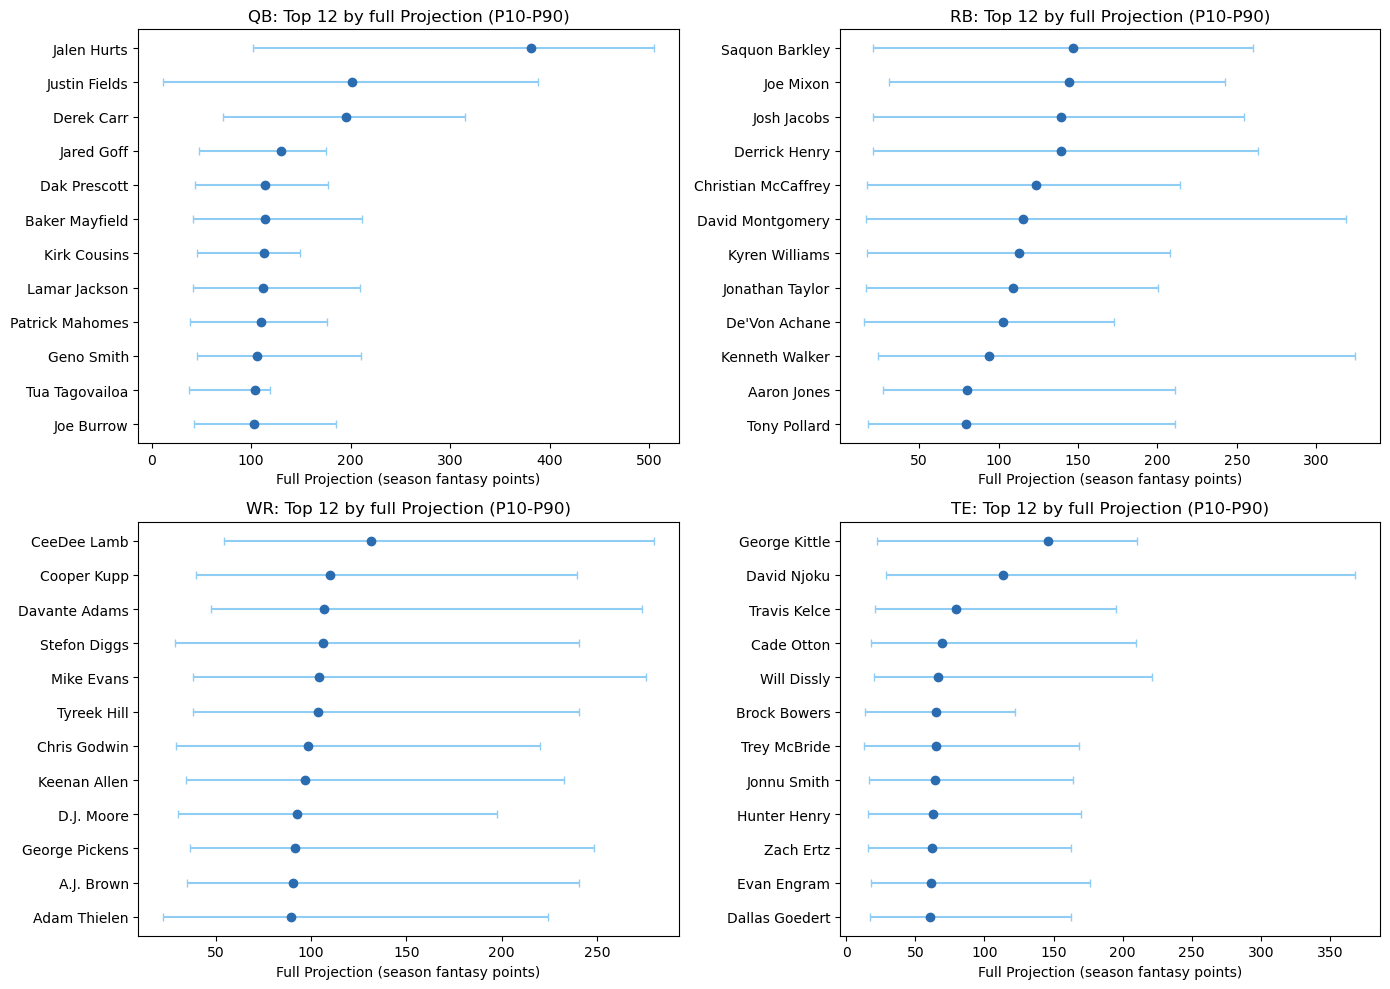

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
positions = ["QB", "RB", "WR", "TE"]

for ax, position in zip(axes.flat, positions):
    top = (
        projections.loc[projections["position"] == position]
        .nlargest(12, "full_projection_p50")
        .sort_values("full_projection_p50")
    )
    y = range(len(top))
    lower_err = top["full_projection_p50"] - top["full_projection_p10"]
    upper_err = top["full_projection_p90"] - top["full_projection_p50"]
    ax.errorbar(
        top["full_projection_p50"], y,
        xerr=[lower_err, upper_err],
        fmt="o", capsize=3, color="#2b6cb0", ecolor="#90cdf4",
    )
    ax.set_yticks(list(y))
    ax.set_yticklabels(top["player_name"])
    ax.set_title(f"{position}: Top 12 by full Projection (P10-P90)")
    ax.set_xlabel("Full Projection (season fantasy points)")

fig.tight_layout()
fig.savefig("../output/boom_bust_ranges.png", dpi=110)
plt.show()

## Walk-Forward Backtest Report

Per position, the Walk-Forward Backtest (seasons 2018-2024, expanding window, 4 splits predicting
2021/2022/2023/2024 — 2024 added once its full-season data became available) compares:

- **Model MAE** vs. **naive-baseline MAE** — mean absolute error of `full_projection_p50` (and the
  naive trailing-average baseline scored + combined with the same Games-Played Estimate) against
  `actual_fantasy_points` (real full-season totals, survivorship-bias-safe per issue #6 — players
  who got hurt and never returned appear with a real zero, not a dropped row).
- **Model Spearman ρ** vs. **ADP Spearman ρ** — how well each ranking (the model's `full_projection_p50`,
  or `-adp` since a lower ADP means an earlier/better expected pick) correlates with the actual
  finish-order ranking (`actual_fantasy_points`). ADP coverage is smaller (`n_with_adp`) since
  Fantasy Football Calculator's free API only covers 2020-2024, and only the subset of backtest rows
  crosswalked to a real name+position match.

In [6]:
report_df = pd.DataFrame(backtest_report).T
report_df.index.name = "position"
report_df[["n", "n_with_adp", "model_mae", "naive_mae", "model_spearman_vs_actual", "adp_spearman_vs_actual"]]

,n,n_with_adp,model_mae,naive_mae,model_spearman_vs_actual,adp_spearman_vs_actual
position,,,,,,
QB,487,96,95.856514,95.795755,0.577358,0.491437
RB,833,211,64.603852,61.514714,0.582418,0.534444
WR,1300,250,61.746044,60.273112,0.627787,0.560134
TE,671,80,44.351409,40.856192,0.587927,0.4521


## Multi-Season Memory Features

Feature-importance inspection of the original v1 model found the single-season `trailing_avg_*`
features dominated every position's model (18-27% importance on the top feature alone), yet that
feature only sees a Veteran's *most recent completed season* — narrower than the naive baseline it
was losing to, which averages over the player's entire career. Three multi-season variants (career
average, last-3-seasons, recency-weighted decay) were backtested alongside the original feature set;
every position improved on **both** MAE and Spearman ρ with its best variant — QB with a 3-season
window, RB/WR/TE with recency-weighted decay — so all four adopted their winning variant as the new
default. Full methodology, numbers, and the decision rationale are in
`docs/research/multi-season-memory-features.md`; the Walk-Forward Backtest numbers above already
reflect these new defaults.

## LightGBM vs. TabFM — the v1 Modeling-Approach Decision

Per ADR-0009 and issue #8: a TabFM (TabPFN-style pretrained tabular foundation model) backend was
built (`ff_model/tabfm_model.py`) as a capability alongside LightGBM, sharing the same
train/predict/quantile-output shape so the two could be swapped and compared apples-to-apples.

**The comparison never ran at production scale.** TabPFN enforces a hard 10,000-row training cap;
this pipeline's expanding-window training set (all seasons through `train_through_season`, per
position) exceeds that cap well before the backtest's later splits. Subsampling down to fit the cap
would compare LightGBM-on-full-data against TabFM-on-a-fraction-of-the-data — not a fair test, and
worse than not testing at all.

**Decision, per ADR-0009's own rule ("TabFM only replaces LightGBM if it clearly wins")**: TabFM does
not clearly win, because it was never run at a comparable scale to make that case. **LightGBM is the
v1 modeling approach for all four positions.** TabFM is documented as a v1 dead end, not deleted —
`tabfm_model.py` and its tests remain in the codebase as a working capability, in case a future
subsampling-based or TabPFN-version-upgrade approach makes a real comparison feasible.

## Related v2-Trigger Findings

- **Depth-Chart Competition Feature** (issue #5): backtested with vs. without on RB; negligible MAE
  difference (60.51 vs. 60.45) at this sample size (3 splits). Feature stays in the model; not shown
  to move the needle yet.
- **Injury-report volume vs. games played** (issue #9): weak, confounded correlation
  (`docs/research/injuries-games-played-correlation.md`) — doesn't trigger a v2 games-played submodel.
  v1's heuristic Games-Played Estimate stands.